In [41]:
import pickle
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
from scipy.stats import linregress
from fooof import FOOOF
import sys
import os
from scipy import signal
from scipy import stats

sys.path.append(os.path.abspath('..'))
from ERPtools import BANDS, process_band_states


In [3]:

with open('/Users/bowmannovey/Desktop/Gangully_Proj/Decay/real_robot_long_data.pkl', 'rb') as f:
    long_data = pickle.load(f)

# Flatten all days into one dict
all_long_combined = {}
for date_folder, sessions in long_data.items():
    for session, files in sessions.items():
        key = f"{date_folder}/{session}"
        all_long_combined[key] = files

print(f"Combined: {len(all_long_combined)} sessions, {sum(len(v) for v in all_long_combined.values())} files")

Combined: 87 sessions, 609 files


In [3]:
all_long_combined.keys()

dict_keys(['20220309/112539', '20220309/112914', '20220309/113255', '20220309/113540', '20220309/113946', '20220309/114223', '20220309/114615', '20220309/114919', '20220309/133610', '20220309/133918', '20220309/134219', '20220309/134728', '20220309/135349', '20220309/141030', '20220309/141427', '20220309/141747', '20220309/142149', '20220309/142427', '20220309/143432', '20220309/143735', '20220309/144038', '20220316/110124', '20220316/110548', '20220316/110829', '20220316/111227', '20220316/111548', '20220316/112353', '20220316/112650', '20220316/133626', '20220316/134119', '20220316/134337', '20220316/134617', '20220316/134837', '20220316/135555', '20220316/135822', '20220325/134220', '20220325/134541', '20220325/134759', '20220325/135332', '20220325/135555', '20220325/142117', '20220325/142610', '20220325/142924', '20220325/143224', '20220325/143511', '20220325/144131', '20220325/144548', '20220325/144855', '20220325/145147', '20220325/145425', '20220325/150344', '20220325/150627', '

In [6]:
all_long_combined["20220309/112539"]["Data0003.mat"].keys()

dict_keys(['AssistVel', 'Block', 'BroadbandData', 'ChStats', 'ClickerDistance', 'ClickerState', 'CursorAssist', 'CursorState', 'ErrorID', 'ErrorStr', 'Events', 'FeatureStats', 'FilteredClickerState', 'IntendedCursorState', 'KalmanFilter', 'KalmanGain', 'NeuralFactors', 'NeuralFeatures', 'NeuralSamps', 'NeuralTime', 'NeuralTimeBR', 'NextTargetID', 'NextTargetPosition', 'Params', 'ProcessedData', 'Reference', 'SelectedTargetID', 'SelectedTargetPosition', 'SmoothedNeuralFeatures', 'StopState', 'TargetID', 'TargetPosition', 'TaskState', 'Time', 'Trial', 'TrialEndTime', 'TrialStartTime'])

In [54]:
len(all_long_combined["20220325/143511"]["Data0007.mat"]["ClickerState"])

40

In [55]:
import numpy as np
(np.array(all_long_combined["20220325/143511"]["Data0007.mat"]["TaskState"]) == 3).sum()

np.int64(40)

In [57]:
import numpy as np
example_file = all_long_combined["20220325/143511"]["Data0007.mat"]
print("Keys:", example_file.keys())
if 'TargetID' in example_file:
    print("TargetID unique values:", np.unique(example_file['TargetID']))
else:
    print("TargetID not in file")


Keys: dict_keys(['AssistVel', 'Block', 'BroadbandData', 'ChStats', 'ClickerDistance', 'ClickerState', 'CursorAssist', 'CursorState', 'ErrorID', 'ErrorStr', 'Events', 'FeatureStats', 'FilteredClickerState', 'IntendedCursorState', 'KalmanFilter', 'KalmanGain', 'NeuralFactors', 'NeuralFeatures', 'NeuralSamps', 'NeuralTime', 'NeuralTimeBR', 'NextTargetID', 'NextTargetPosition', 'Params', 'ProcessedData', 'Reference', 'SelectedTargetID', 'SelectedTargetPosition', 'SmoothedNeuralFeatures', 'StopState', 'TargetID', 'TargetPosition', 'TaskState', 'Time', 'Trial', 'TrialEndTime', 'TrialStartTime'])
TargetID unique values: [7.]


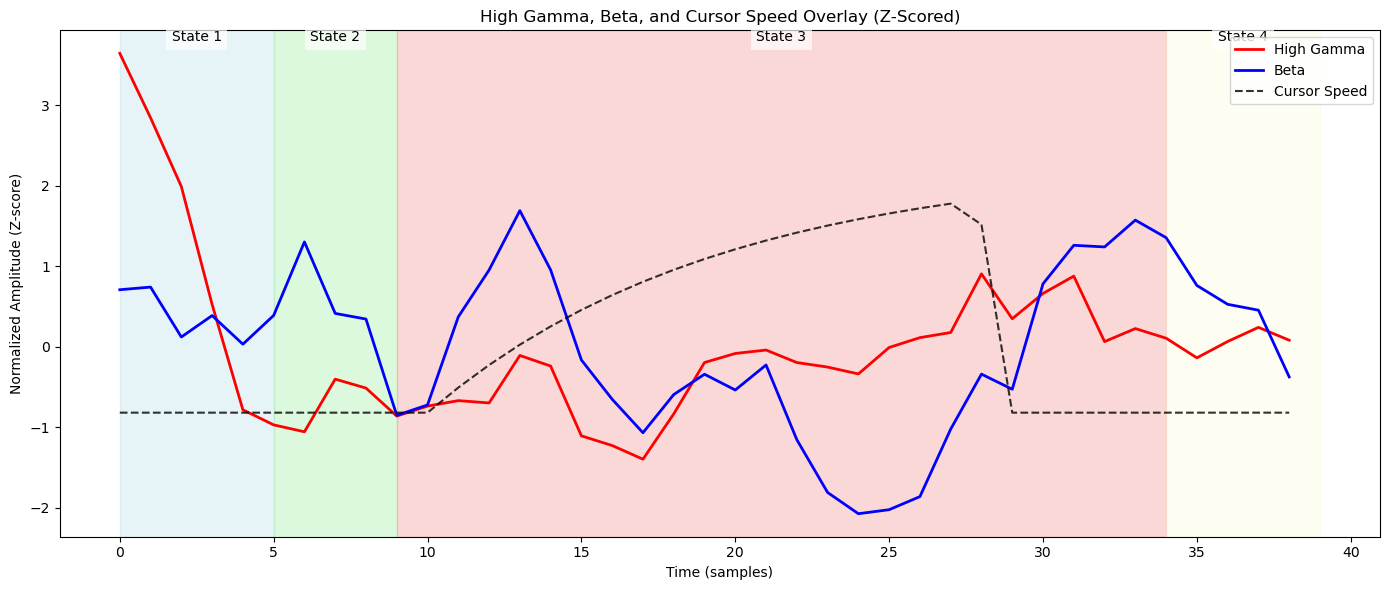

In [18]:
# Let's plot High Gamma, Beta, and Kinetics (CursorState) for an example file
session_key = list(all_long_combined.keys())[0] # Pick the first session
file_key = list(all_long_combined[session_key].keys())[1] # Pick the first file
data = all_long_combined[session_key][file_key]

# Assuming CursorState is something like [features x time] or [time x features]
cursor_state = data['CursorState']

# x, y, z velocity are at indices 3, 4, 5 (0-indexed)
vel_x = cursor_state[:, 3]
vel_y = cursor_state[:, 4]
vel_z = cursor_state[:, 5]

# Calculate overall speed using the Euclidean norm of velocities
speed = np.sqrt(vel_x**2 + vel_y**2 + vel_z**2)

# Extract Neural Features for the frequency bands matching ERPtools.py
# (SmoothedNeuralFeatures typically shapes as [time, 896] -> transposed to [896, time])
features = np.array(data['SmoothedNeuralFeatures']).squeeze().T

# Frequency band indices from ERPtools.py
# Beta: 512 to 640
# HG: 768 to 896 (end)
beta_data = features[512:640, :]
hg_data = features[768:, :]

# Average across all 128 channels for a global view 
beta_mean = np.mean(beta_data, axis=0)
hg_mean = np.mean(hg_data, axis=0)

# Normalize the data (Z-score) so they fit nicely on a single plot axis
def normalize(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-10)

hg_norm = normalize(hg_mean)
beta_norm = normalize(beta_mean)
speed_norm = normalize(speed)

# Retrieve Task States to overlay
task_state = np.array(data['TaskState']).flatten()
state_changes = np.where(np.diff(task_state) != 0)[0] + 1
change_indices = [0] + state_changes.tolist() + [len(task_state)]
state_ids = [int(task_state[0])] + [int(s) for s in task_state[state_changes]]

state_colors = {
    1: 'lightblue',
    2: 'lightgreen',
    3: 'lightcoral',
    4: 'lightgoldenrodyellow'
}

# Plotting on a single overlay
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(hg_norm, color='red', label='High Gamma', linewidth=2)
ax.plot(beta_norm, color='blue', label='Beta', linewidth=2)
ax.plot(speed_norm, color='black', label='Cursor Speed', linestyle='--', alpha=0.8)

ax.set_title('High Gamma, Beta, and Cursor Speed Overlay (Z-Scored)')
ax.set_xlabel('Time (samples)')
ax.set_ylabel('Normalized Amplitude (Z-score)')
ax.legend(loc='upper right')

# Overlay states on the plot
y_min, y_max = ax.get_ylim()
for i in range(len(change_indices) - 1):
    start_idx = change_indices[i]
    end_idx = change_indices[i+1]
    s_id = state_ids[i]
    
    # Shade the background based on the state
    color = state_colors.get(s_id, 'lightgray')
    ax.axvspan(start_idx, end_idx, color=color, alpha=0.3)
    
    # Add labels at the top
    ax.text(start_idx + (end_idx - start_idx)/2, y_max, f'State {s_id}', 
            horizontalalignment='center', verticalalignment='top', fontsize=10, 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

fig.tight_layout()
plt.show()

In [8]:
import os
import scipy.ndimage as ndimage
import numpy as np
import matplotlib.pyplot as plt

# Define state colors mapping
state_colors = {
    1: 'lightblue',
    2: 'lightgreen',
    3: 'lightcoral',
    4: 'lightgoldenrodyellow'
}

# Iterate over ALL sessions and ALL files
for session_key, files_dict in all_long_combined.items():
    # Create a directory for the current session to keep things organized
    save_dir = os.path.join("saved_plots", session_key.replace("/", "_"))
    os.makedirs(save_dir, exist_ok=True)
    
    for f_key, data in files_dict.items():
        fs = float(np.array(data['Params']['UpdateRate']).flat[0])
        
        # 1. Kinetics (Cursor Speed)
        cursor_state = data['CursorState']
        if cursor_state.shape[0] < cursor_state.shape[1]:
            speed = np.sqrt(cursor_state[3,:]**2 + cursor_state[4,:]**2 + cursor_state[5,:]**2)
        else:
            speed = np.sqrt(cursor_state[:,3]**2 + cursor_state[:,4]**2 + cursor_state[:,5]**2)
            
        # 2. Neural Features
        features = np.array(data['SmoothedNeuralFeatures']).squeeze().T
        beta_mean = np.mean(features[512:640, :], axis=0)
        hg_mean = np.mean(features[768:, :], axis=0)
        
        # 3. Locate Onset and Trial End bounds
        task_state = np.array(data['TaskState']).flatten()
        
        # Locate all states to layer in backgrounds
        state_changes = np.where(np.diff(task_state) != 0)[0] + 1
        change_indices = [0] + state_changes.tolist() + [len(task_state)]
        state_ids = [int(task_state[0])] + [int(s) for s in task_state[state_changes]]
        
        s2_idx = np.where(task_state == 2)[0] # Often considered target/cue onset
        s4_idx = np.where(task_state == 4)[0] # Often considered trial end / success
        
        onset_idx = s2_idx[0] if len(s2_idx) > 0 else 0
        end_idx = s4_idx[0] if len(s4_idx) > 0 else len(task_state)-1
        
        # Create time axis in seconds, relative to onset
        t_axis = (np.arange(len(task_state)) - onset_idx) / fs
        t_end = (end_idx - onset_idx) / fs
        
        # 4. Use raw data (removed heavy Gaussian smoothing)
        hg_smooth = hg_mean
        beta_smooth = beta_mean
        speed_smooth = speed
        
        # 5. Z-score normalization
        hg_norm = (hg_smooth - np.mean(hg_smooth)) / (np.std(hg_smooth) + 1e-10)
        beta_norm = (beta_smooth - np.mean(beta_smooth)) / (np.std(beta_smooth) + 1e-10)
        speed_norm = (speed_smooth - np.mean(speed_smooth)) / (np.std(speed_smooth) + 1e-10)
        
        # Plotting overlaid signals per trial
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.set_title(f'Session: {session_key} | File: {f_key}')
        
        ax.plot(t_axis, hg_norm, color='#e41a1c', label='High Gamma', linewidth=1.5)
        ax.plot(t_axis, beta_norm, color='#377eb8', label='Beta', linewidth=1.5)
        ax.plot(t_axis, speed_norm, color='gray', label='Speed (Kinetics)', linewidth=1.5, linestyle='--')
        
        ax.set_ylabel('Z-Score')
        ax.set_xlabel('Time from onset (s)')
        
        # Add the Task State overlays based on time
        y_min, y_max = [-4, 4]
        ax.set_ylim([y_min, y_max])
        
        for i in range(len(change_indices) - 1):
            s_idx = change_indices[i]
            e_idx = change_indices[i+1]
            s_id = state_ids[i]
            
            # Convert indices to time relative to onset
            t_start_shade = (s_idx - onset_idx) / fs
            t_end_shade = (e_idx - onset_idx) / fs
            
            # Shade the background based on the state
            color = state_colors.get(s_id, 'lightgray')
            ax.axvspan(t_start_shade, t_end_shade, color=color, alpha=0.3)
            
            # Add labels at the top
            ax.text(t_start_shade + (t_end_shade - t_start_shade)/2, y_max - 0.2, f'State {s_id}', 
                    horizontalalignment='center', verticalalignment='top', fontsize=9, 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
            
        ax.set_xlim([t_axis[0], t_axis[-1]])
        ax.legend(loc='lower right')

        fig.tight_layout()
        
        # Save the plot instead of showing it
        safe_f_key = f_key.replace(".mat", "")
        save_path = os.path.join(save_dir, f"{safe_f_key}.png")
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig) # Close the figure to free up memory

print("Finished saving all plots to the 'saved_plots' directory with state overlays!")

Finished saving all plots to the 'saved_plots' directory with state overlays!


In [4]:
target_action = 7
target_7_data = {}

for session_key, files_dict in all_long_combined.items():
    filtered_files = {}
    for f_key, data in files_dict.items():
        if 'TargetID' in data:
            # Check if our target action is present anywhere in the TargetID array for this file
            target_array = np.array(data['TargetID']).flatten()
            if target_action in target_array:
                filtered_files[f_key] = data
                
    # If this session has any files matching target 7, add them to our filtered dictionary
    if filtered_files:
        target_7_data[session_key] = filtered_files

# Print summary of the filtering
print(f"Filtered data to Target {target_action} (Clicking):")
print(f"Original Data: {len(all_long_combined)} sessions, {sum(len(v) for v in all_long_combined.values())} files")
print(f"Filtered Data: {len(target_7_data)} sessions, {sum(len(v) for v in target_7_data.values())} files")

Filtered data to Target 7 (Clicking):
Original Data: 87 sessions, 609 files
Filtered Data: 87 sessions, 87 files


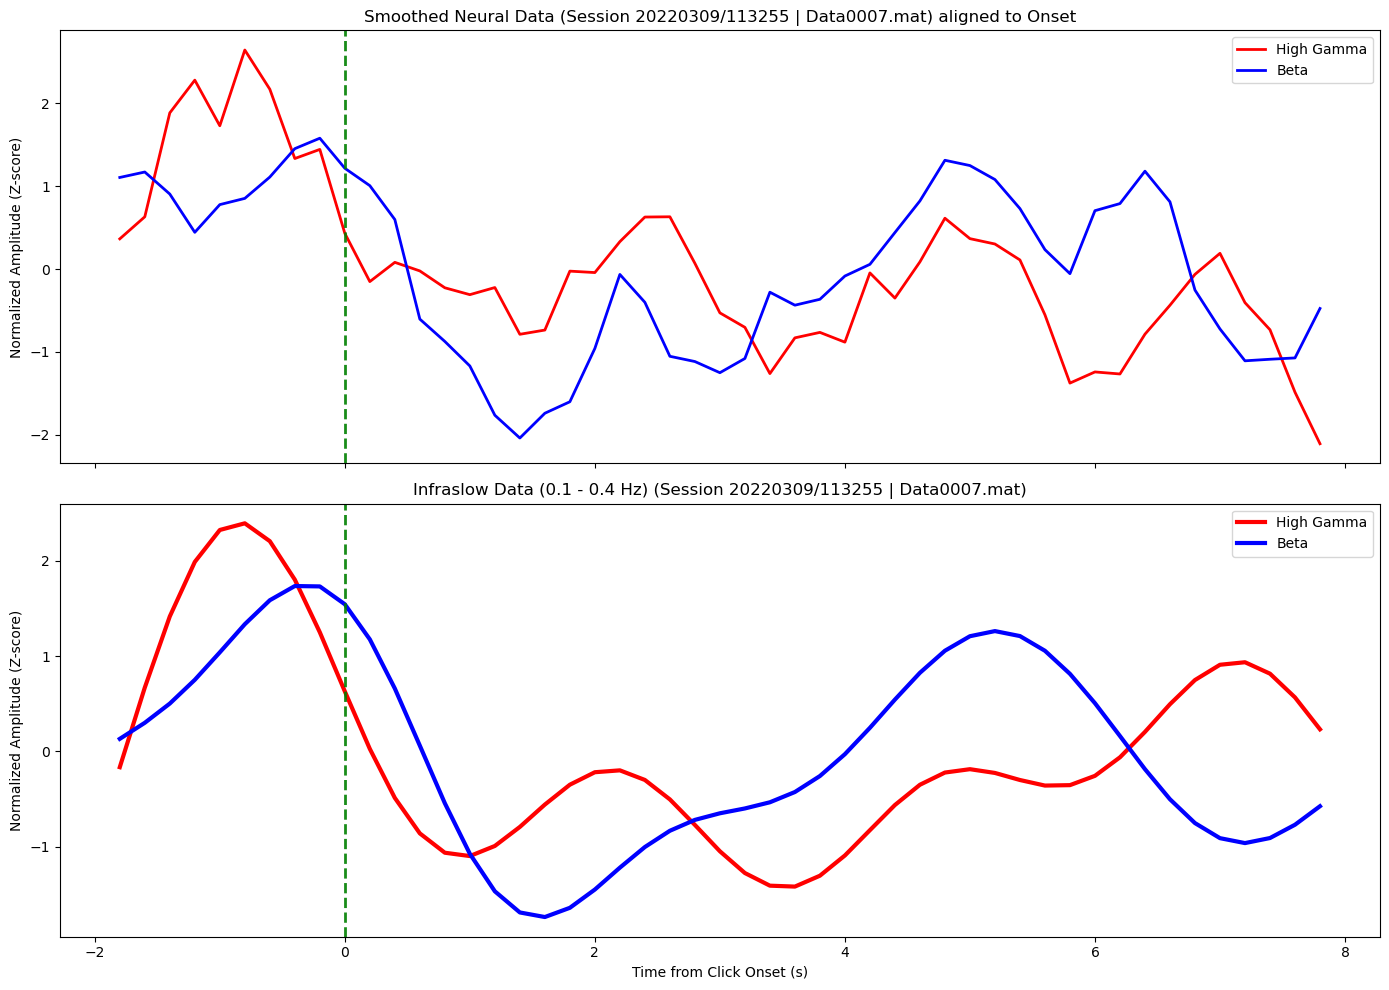

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

# Let's plot High Gamma, Beta for an example Target 7 file
session_key = list(target_7_data.keys())[2] # Pick the first session
file_key = list(target_7_data[session_key].keys())[0] # Pick the first file
data = target_7_data[session_key][file_key]

fs = float(np.array(data['Params']['UpdateRate']).flat[0])

# 1. Extract Neural Features (Smoothed)
features = np.array(data['SmoothedNeuralFeatures']).squeeze().T
beta_mean = np.mean(features[512:640, :], axis=0) # Beta
hg_mean = np.mean(features[768:, :], axis=0)      # High Gamma

# 2. Apply Infraslow Filter (Band-pass, 0.1 to 0.4 Hz)
nyquist = 0.5 * fs
lowcut = 0.1 
highcut = 0.4  

b, a = signal.butter(4, [lowcut / nyquist, highcut / nyquist], btype='bandpass')
# Padlen needs to be smaller than the signal length for filtfilt to work on short trials
padlen = min(len(hg_mean) - 1, 15) 
hg_infraslow = signal.filtfilt(b, a, hg_mean, padlen=padlen)
beta_infraslow = signal.filtfilt(b, a, beta_mean, padlen=padlen)

# 3. Z-score normalization for viewing them
hg_norm = (hg_mean - np.mean(hg_mean)) / (np.std(hg_mean) + 1e-10)
beta_norm = (beta_mean - np.mean(beta_mean)) / (np.std(beta_mean) + 1e-10)

hg_infra_norm = (hg_infraslow - np.mean(hg_infraslow)) / (np.std(hg_infraslow) + 1e-10)
beta_infra_norm = (beta_infraslow - np.mean(beta_infraslow)) / (np.std(beta_infraslow) + 1e-10)

# 4. Retrieve Task States to calculate onset
task_state = np.array(data['TaskState']).flatten()

# Find onset of the Clicking action (TaskState == 3)
s3_idx = np.where(task_state == 3)[0]
onset_idx = s3_idx[0] if len(s3_idx) > 0 else 0

# Neural features time axis (t=0 is now aligned to State 3 onset)
t_axis_neural = (np.arange(len(hg_norm)) - onset_idx) / fs

# 5. Plotting on two separate subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# Top Plot: Smoothed Neural Data
ax1.plot(t_axis_neural, hg_norm, color='red', label='High Gamma', linewidth=2)
ax1.plot(t_axis_neural, beta_norm, color='blue', label='Beta', linewidth=2)
ax1.set_title(f'Smoothed Neural Data (Session {session_key} | {file_key}) aligned to Onset')
ax1.set_ylabel('Normalized Amplitude (Z-score)')
ax1.legend(loc='upper right')
ax1.axvline(x=0, color='green', linestyle='--', alpha=0.9, linewidth=2)

# Bottom Plot: Infraslow Neural Data
ax2.plot(t_axis_neural, hg_infra_norm, color='red', label='High Gamma', linewidth=3)
ax2.plot(t_axis_neural, beta_infra_norm, color='blue', label='Beta', linewidth=3)
ax2.set_title(f'Infraslow Data (0.1 - 0.4 Hz) (Session {session_key} | {file_key})')
ax2.set_xlabel('Time from Click Onset (s)')
ax2.set_ylabel('Normalized Amplitude (Z-score)')
ax2.legend(loc='upper right')
ax2.axvline(x=0, color='green', linestyle='--', alpha=0.9, linewidth=2)

fig.tight_layout()
plt.show()

Peak Correlation: 0.493
Time Lag: 0.200 seconds
Positive lag means High Gamma precedes Beta


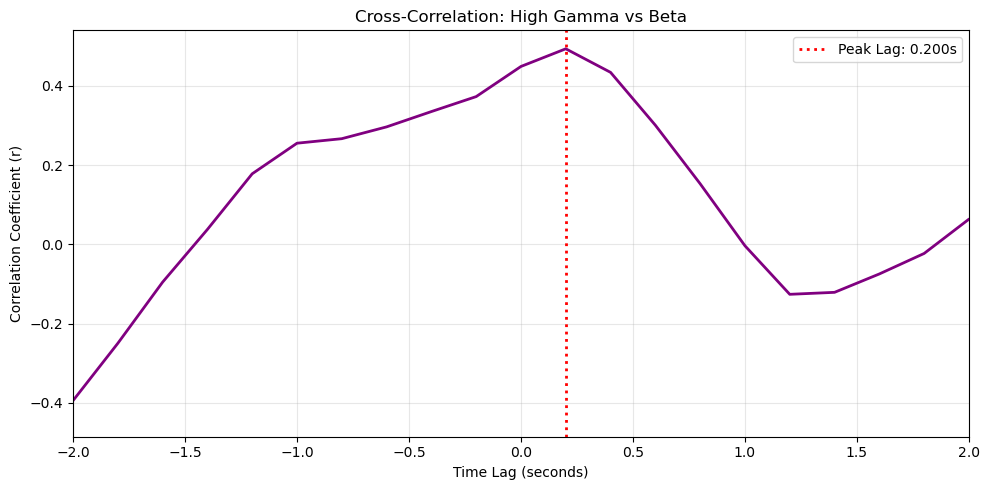

In [7]:
# 1. Calculate the cross-correlation
# We use mode='full' to get all possible lags
correlation = signal.correlate(hg_norm, beta_norm, mode='full')

# Normalize the correlation to be between -1 and 1
# This is equivalent to Pearson correlation coefficient at each lag
correlation /= (len(hg_norm) * np.std(hg_norm) * np.std(beta_norm))

# 2. Create the lag axis (in seconds)
# fs is the sampling rate (UpdateRate) you extracted
lags = signal.correlation_lags(len(hg_norm), len(beta_norm), mode='full')
time_lags = lags / fs

# 3. Find the peak correlation and its corresponding time lag
peak_idx = np.argmax(np.abs(correlation))
peak_lag = time_lags[peak_idx]
peak_corr = correlation[peak_idx]

print(f"Peak Correlation: {peak_corr:.3f}")
print(f"Time Lag: {peak_lag:.3f} seconds")
if peak_lag < 0:
    print("Negative lag means Beta precedes High Gamma")
elif peak_lag > 0:
    print("Positive lag means High Gamma precedes Beta")
else:
    print("No lag, signals are perfectly synchronized")

# 4. Plot the cross-correlation
plt.figure(figsize=(10, 5))
plt.plot(time_lags, correlation, color='purple', linewidth=2)
plt.axvline(x=peak_lag, color='red', linestyle=':', linewidth=2, 
            label=f'Peak Lag: {peak_lag:.3f}s')

plt.title('Cross-Correlation: High Gamma vs Beta')
plt.xlabel('Time Lag (seconds)')
plt.ylabel('Correlation Coefficient (r)')
plt.xlim([-2, 2]) # Zoom in on +/- 2 seconds for better visibility
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
def plot_band_xcorr(sig1, sig2, fs, sig1_name='High Gamma', sig2_name='Beta', title=None, show_plot=True):
    """
    Calculates and optionally plots the cross-correlation between two signals.
    
    Parameters:
    - sig1, sig2: 1D numpy arrays of the normalized signals
    - fs: float, sampling rate in Hz
    - sig1_name: string, name of the first signal (stays fixed)
    - sig2_name: string, name of the second signal (slides across sig1)
    - title: string, optional custom title for the plot
    - show_plot: boolean, whether to render the matplotlib plot
    
    Returns:
    - peak_lag (float): the time lag in seconds where the signals match best
    - peak_corr (float): the Pearson r correlation score at that lag
    """
    # 1. Calculate the cross-correlation
    correlation = signal.correlate(sig1, sig2, mode='full')
    
    # Normalize to get Pearson correlation coefficient
    correlation /= (len(sig1) * (np.std(sig1) + 1e-10) * (np.std(sig2) + 1e-10))
    
    # 2. Create the lag axis (in seconds)
    lags = signal.correlation_lags(len(sig1), len(sig2), mode='full')
    time_lags = lags / fs
    
    # 3. Find the peak correlation and its corresponding time lag
    peak_idx = np.argmax(np.abs(correlation))
    peak_lag = time_lags[peak_idx]
    peak_corr = correlation[peak_idx]
    
    # 4. Optional Plotting
    if show_plot:
        plt.figure(figsize=(8, 4))
        plt.plot(time_lags, correlation, color='purple', linewidth=2)
        plt.axvline(x=peak_lag, color='red', linestyle=':', linewidth=2, 
                    label=f'Peak Lag: {peak_lag:.3f}s\nPeak r = {peak_corr:.2f}')
        
        plot_title = title if title else f'Cross-Correlation: {sig1_name} vs {sig2_name}'
        plt.title(plot_title)
        plt.xlabel('Time Lag (seconds)')
        plt.ylabel('Correlation Coefficient (r)')
        plt.xlim([-2.0, 2.0]) # Zoom in for clarity
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    return peak_lag, peak_corr

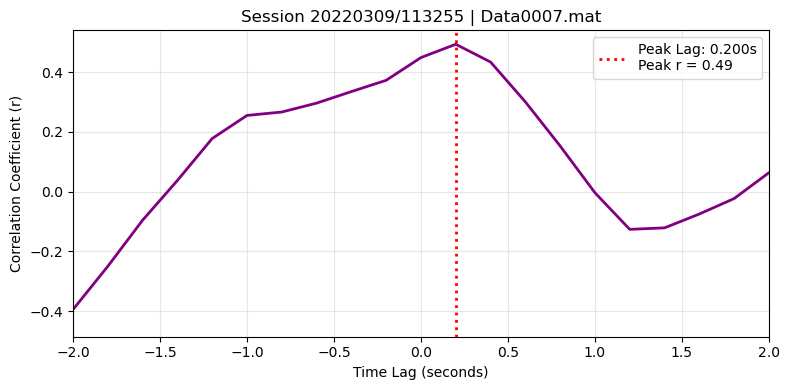

Saved lag: 0.2, Saved r: 0.4934388621275097


In [11]:
# Just pass in the arrays you've already extracted
lag, corr = plot_band_xcorr(hg_norm, beta_norm, fs, 
                            title=f"Session {session_key} | {file_key}")
print(f"Saved lag: {lag}, Saved r: {corr}")

Starting xcorr processing for 87 sessions...


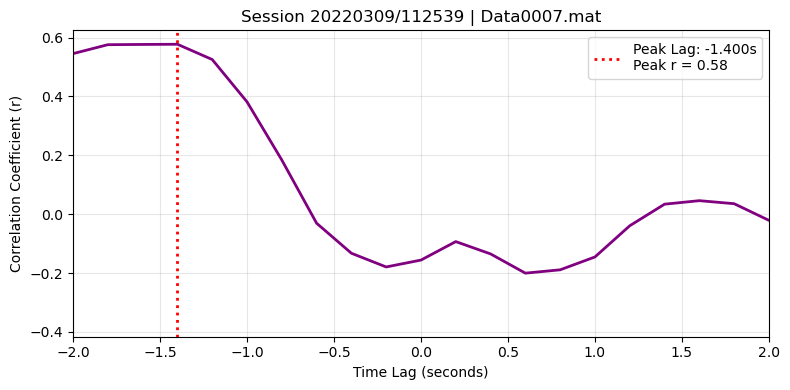

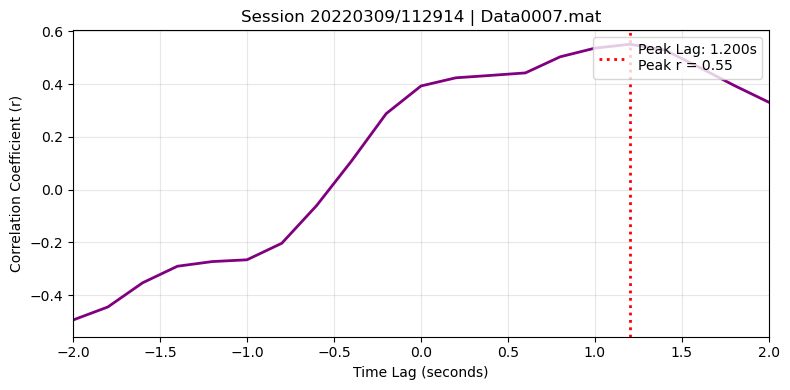

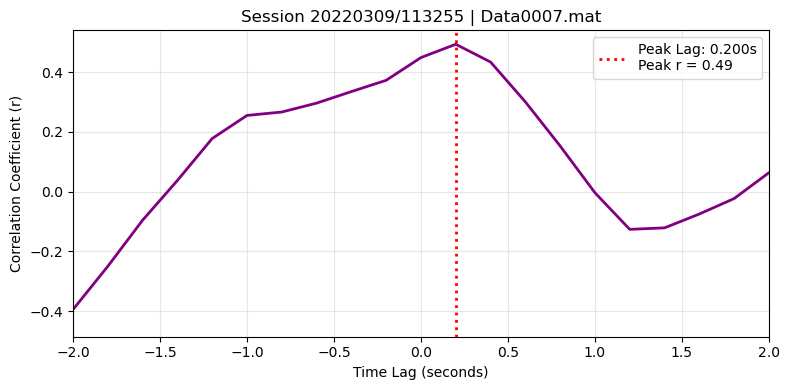

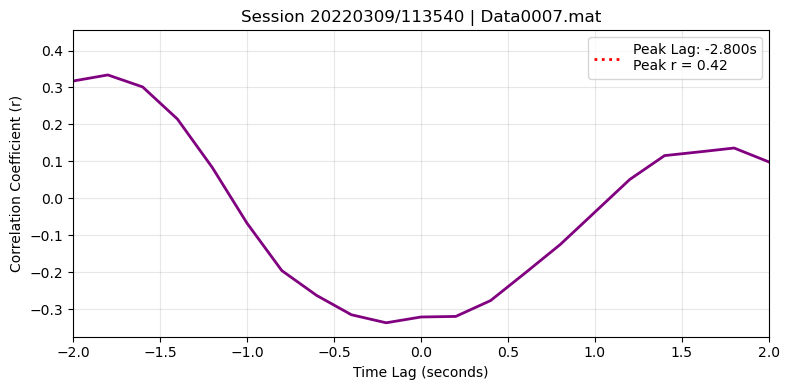

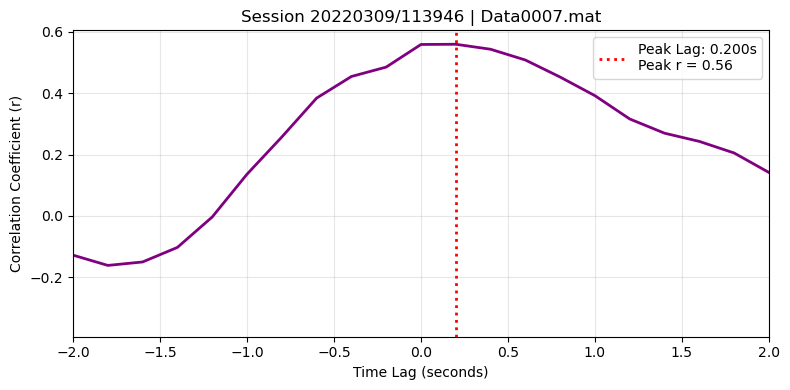

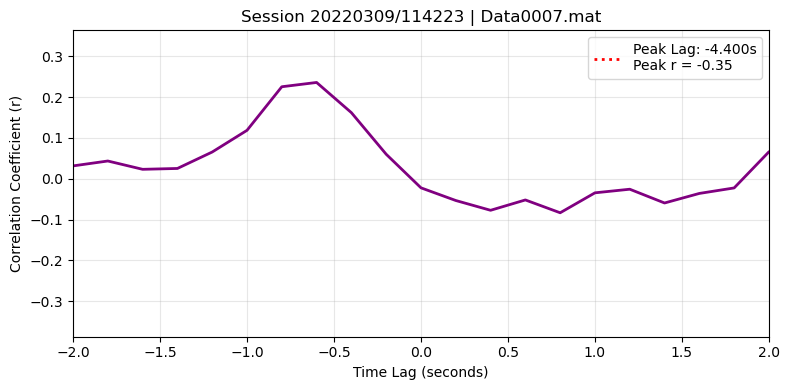

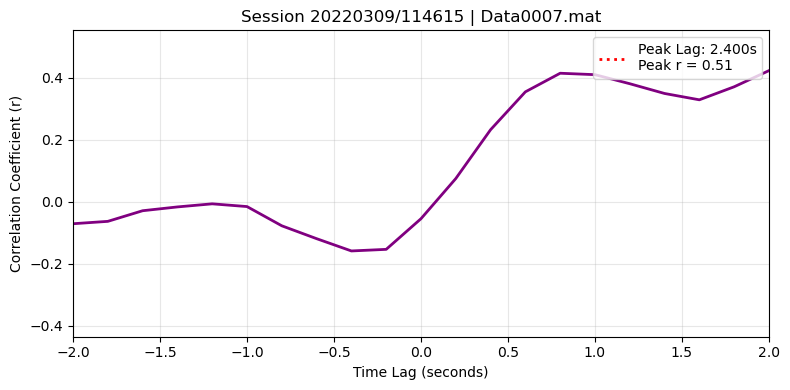

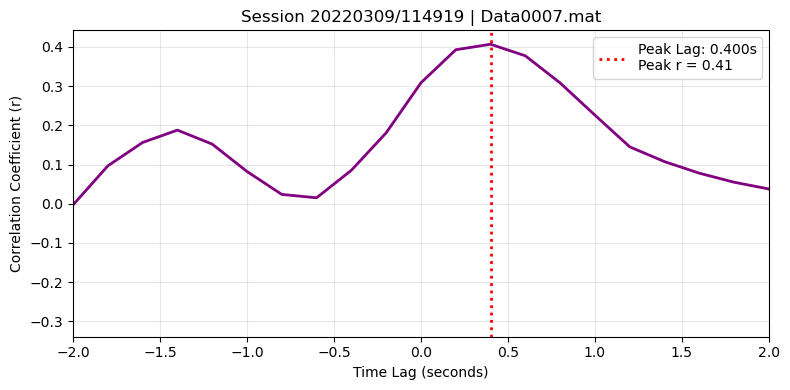

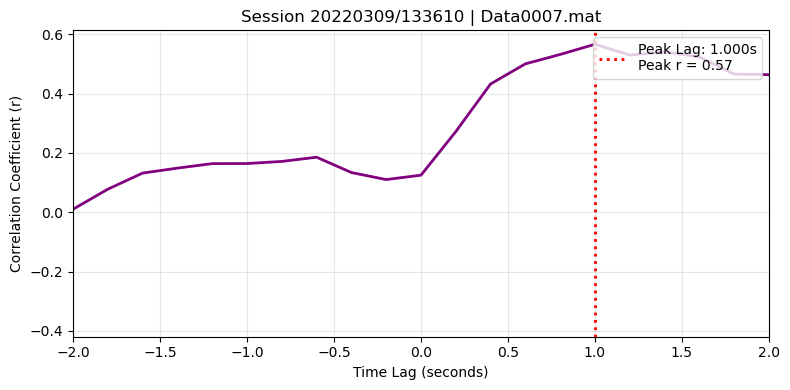

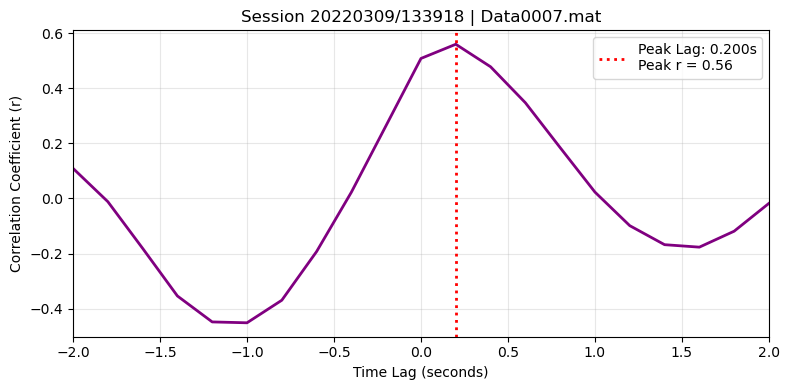

--------------------------------------------------
Processing Complete! Calculated xcorr for 87 total trials.
Overall Average Time Lag: -0.607 seconds
Overall Average Peak Correlation (r): 0.274


In [13]:
all_lags = []
all_corrs = []
session_file_labels = []

# Limit visual plots so the notebook doesn't freeze (set to None to plot ALL)
max_plots = 10  
plots_shown = 0

print(f"Starting xcorr processing for {len(target_7_data)} sessions...")

for session_key, files_dict in target_7_data.items():
    for file_key, data in files_dict.items():
        
        # 1. Extract params and features
        fs = float(np.array(data['Params']['UpdateRate']).flat[0])
        
        features = np.array(data['SmoothedNeuralFeatures']).squeeze().T
        beta_mean = np.mean(features[512:640, :], axis=0) # Beta
        hg_mean = np.mean(features[768:, :], axis=0)      # High Gamma
        
        # 2. Normalize
        hg_norm = (hg_mean - np.mean(hg_mean)) / (np.std(hg_mean) + 1e-10)
        beta_norm = (beta_mean - np.mean(beta_mean)) / (np.std(beta_mean) + 1e-10)
        
        # 3. Determine if we should render the plot this loop
        do_plot = True if (max_plots is None or plots_shown < max_plots) else False
        
        # 4. Run the function
        lag, corr = plot_band_xcorr(
            hg_norm, beta_norm, fs, 
            title=f"Session {session_key} | {file_key}",
            show_plot=do_plot
        )
        
        if do_plot:
            plots_shown += 1
            
        # 5. Save the data for final stats
        all_lags.append(lag)
        all_corrs.append(corr)
        session_file_labels.append(f"{session_key}_{file_key}")

# Convert to numpy arrays for easy math later
all_lags = np.array(all_lags)
all_corrs = np.array(all_corrs)

print("--------------------------------------------------")
print(f"Processing Complete! Calculated xcorr for {len(all_lags)} total trials.")
print(f"Overall Average Time Lag: {np.mean(all_lags):.3f} seconds")
print(f"Overall Average Peak Correlation (r): {np.mean(all_corrs):.3f}")

Now plotting -> Session: 20220309/113946 | File: Data0007.mat


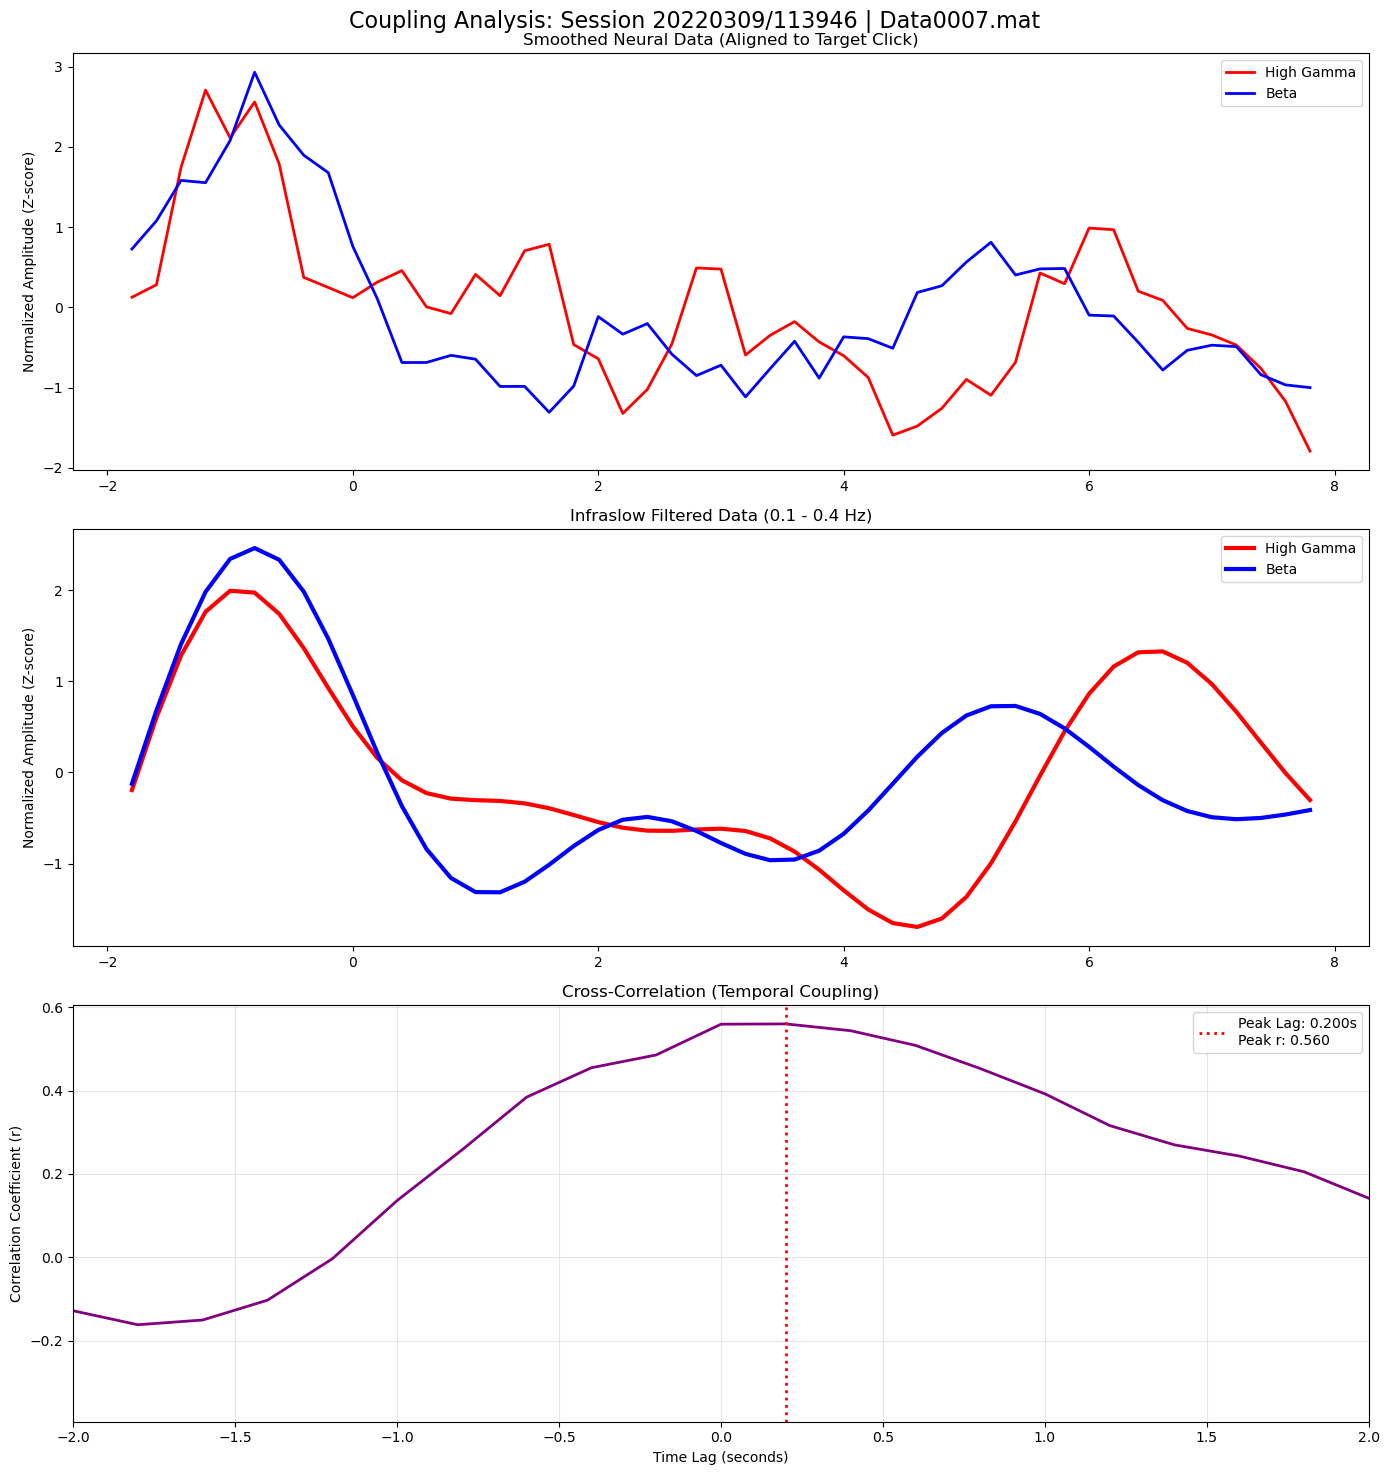

In [34]:
# Extract the data based on your numbers
session_key = list(target_7_data.keys())[4]
file_key = list(target_7_data[session_key].keys())[0]
data = target_7_data[session_key][file_key]

print(f"Now plotting -> Session: {session_key} | File: {file_key}")

# -------------------------------------------------------
# Define a quick z-score helper
def zscore(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-10)

# 1. Extract Neural Features
fs = float(np.array(data['Params']['UpdateRate']).flat[0])
features = np.array(data['SmoothedNeuralFeatures']).squeeze().T
beta_mean = np.mean(features[512:640, :], axis=0) # Beta
hg_mean = np.mean(features[768:, :], axis=0)      # High Gamma

# 2. Infraslow Filter
nyquist = 0.5 * fs
b, a = signal.butter(4, [0.1 / nyquist, 0.4 / nyquist], btype='bandpass')
padlen = min(len(hg_mean) - 1, 15) 
hg_infraslow = signal.filtfilt(b, a, hg_mean, padlen=padlen)
beta_infraslow = signal.filtfilt(b, a, beta_mean, padlen=padlen)

# 3. Z-score normalization commands
hg_norm = zscore(hg_mean)
beta_norm = zscore(beta_mean)
hg_infra_norm = zscore(hg_infraslow)
beta_infra_norm = zscore(beta_infraslow)

# 4. Task State for time alignment
task_state = np.array(data['TaskState']).flatten()
s3_idx = np.where(task_state == 3)[0]
onset_idx = s3_idx[0] if len(s3_idx) > 0 else 0
t_axis_neural = (np.arange(len(hg_norm)) - onset_idx) / fs

# 5. Cross-Correlation calc
correlation = signal.correlate(hg_norm, beta_norm, mode='full')
correlation /= (len(hg_norm) * np.std(hg_norm) * np.std(beta_norm))
time_lags = signal.correlation_lags(len(hg_norm), len(beta_norm), mode='full') / fs
peak_idx = np.argmax(np.abs(correlation))
peak_lag = time_lags[peak_idx]
peak_corr = correlation[peak_idx]

# ----------------- PLOTTING STACK -----------------
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 15))
fig.suptitle(f'Coupling Analysis: Session {session_key} | {file_key}', fontsize=16, y=0.98)

# Panel 1: Smoothed Neural Data
axes[0].plot(t_axis_neural, hg_norm, color='red', label='High Gamma', linewidth=2)
axes[0].plot(t_axis_neural, beta_norm, color='blue', label='Beta', linewidth=2)
axes[0].set_title('Smoothed Neural Data (Aligned to Target Click)')
axes[0].set_ylabel('Normalized Amplitude (Z-score)')
axes[0].legend(loc='upper right')

# Panel 2: Infraslow Neural Data
axes[1].plot(t_axis_neural, hg_infra_norm, color='red', label='High Gamma', linewidth=3)
axes[1].plot(t_axis_neural, beta_infra_norm, color='blue', label='Beta', linewidth=3)
axes[1].set_title('Infraslow Filtered Data (0.1 - 0.4 Hz)')
axes[1].set_ylabel('Normalized Amplitude (Z-score)')
axes[1].legend(loc='upper right')

# Panel 3: Cross-Correlation
axes[2].plot(time_lags, correlation, color='purple', linewidth=2)
axes[2].axvline(x=peak_lag, color='red', linestyle=':', linewidth=2, 
            label=f'Peak Lag: {peak_lag:.3f}s\nPeak r: {peak_corr:.3f}')
axes[2].set_title('Cross-Correlation (Temporal Coupling)')
axes[2].set_xlabel('Time Lag (seconds)')
axes[2].set_ylabel('Correlation Coefficient (r)')
axes[2].set_xlim([-2, 2]) # Zoom in for visibility
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
xcorr_data = []
for i in range(len(target_7_data.keys())):
    session_key = list(target_7_data.keys())[i]
    file_key = list(target_7_data[session_key].keys())[0]
    data = target_7_data[session_key][file_key]

    print(f"Now plotting -> Session: {session_key} | File: {file_key}")

    # -------------------------------------------------------
    # Define a quick z-score helper
    def zscore(x):
        return (x - np.mean(x)) / (np.std(x) + 1e-10)

    # 1. Extract Neural Features
    fs = float(np.array(data['Params']['UpdateRate']).flat[0])
    features = np.array(data['SmoothedNeuralFeatures']).squeeze().T
    beta_mean = np.mean(features[512:640, :], axis=0) # Beta
    hg_mean = np.mean(features[768:, :], axis=0)      # High Gamma

    # 2. Infraslow Filter
    nyquist = 0.5 * fs
    b, a = signal.butter(4, [0.1 / nyquist, 0.4 / nyquist], btype='bandpass')
    padlen = min(len(hg_mean) - 1, 15) 
    hg_infraslow = signal.filtfilt(b, a, hg_mean, padlen=padlen)
    beta_infraslow = signal.filtfilt(b, a, beta_mean, padlen=padlen)

    # 3. Z-score normalization commands
    hg_norm = zscore(hg_mean)
    beta_norm = zscore(beta_mean)
    hg_infra_norm = zscore(hg_infraslow)
    beta_infra_norm = zscore(beta_infraslow)

    # 4. Task State for time alignment
    task_state = np.array(data['TaskState']).flatten()
    s3_idx = np.where(task_state == 3)[0]
    onset_idx = s3_idx[0] if len(s3_idx) > 0 else 0
    t_axis_neural = (np.arange(len(hg_norm)) - onset_idx) / fs

    # 5. Cross-Correlation calc
    correlation = signal.correlate(hg_norm, beta_norm, mode='full')
    correlation /= (len(hg_norm) * np.std(hg_norm) * np.std(beta_norm))
    time_lags = signal.correlation_lags(len(hg_norm), len(beta_norm), mode='full') / fs
    peak_idx = np.argmax(np.abs(correlation))
    peak_lag = time_lags[peak_idx]
    peak_corr = correlation[peak_idx]

    xcorr_data.append({
        'session': session_key,
        'file': file_key,
        'time_lags': time_lags,
        'correlation': correlation,
        'peak_lag': peak_lag,
        'peak_corr': peak_corr
    })

    # ----------------- PLOTTING STACK -----------------
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 15))
    fig.suptitle(f'Coupling Analysis: Session {session_key} | {file_key}', fontsize=16, y=0.98)

    # Panel 1: Smoothed Neural Data
    axes[0].plot(t_axis_neural, hg_norm, color='red', label='High Gamma', linewidth=2)
    axes[0].plot(t_axis_neural, beta_norm, color='blue', label='Beta', linewidth=2)
    axes[0].set_title('Smoothed Neural Data (Aligned to Target Click)')
    axes[0].set_ylabel('Normalized Amplitude (Z-score)')
    axes[0].legend(loc='upper right')

    # Panel 2: Infraslow Neural Data
    axes[1].plot(t_axis_neural, hg_infra_norm, color='red', label='High Gamma', linewidth=3)
    axes[1].plot(t_axis_neural, beta_infra_norm, color='blue', label='Beta', linewidth=3)
    axes[1].set_title('Infraslow Filtered Data (0.1 - 0.4 Hz)')
    axes[1].set_ylabel('Normalized Amplitude (Z-score)')
    axes[1].legend(loc='upper right')

    # Panel 3: Cross-Correlation
    axes[2].plot(time_lags, correlation, color='purple', linewidth=2)
    axes[2].axvline(x=peak_lag, color='red', linestyle=':', linewidth=2, 
                label=f'Peak Lag: {peak_lag:.3f}s\nPeak r: {peak_corr:.3f}')
    axes[2].set_title('Cross-Correlation (Temporal Coupling)')
    axes[2].set_xlabel('Time Lag (seconds)')
    axes[2].set_ylabel('Correlation Coefficient (r)')
    axes[2].set_xlim([-2, 2]) # Zoom in for visibility
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig(f"/Users/bowmannovey/Desktop/Gangully_Proj/Decay/Kinetic_plots/XCorr_plots/{session_key.replace('/', '_')}_{file_key.replace('.mat', '')}.png")
    plt.close(fig) # Highly recommended so your notebook doesn't crash from drawing 100+ plots

Now plotting -> Session: 20220309/112539 | File: Data0007.mat
Now plotting -> Session: 20220309/112914 | File: Data0007.mat
Now plotting -> Session: 20220309/113255 | File: Data0007.mat
Now plotting -> Session: 20220309/113540 | File: Data0007.mat
Now plotting -> Session: 20220309/113946 | File: Data0007.mat
Now plotting -> Session: 20220309/114223 | File: Data0007.mat
Now plotting -> Session: 20220309/114615 | File: Data0007.mat
Now plotting -> Session: 20220309/114919 | File: Data0007.mat
Now plotting -> Session: 20220309/133610 | File: Data0007.mat
Now plotting -> Session: 20220309/133918 | File: Data0007.mat
Now plotting -> Session: 20220309/134219 | File: Data0007.mat
Now plotting -> Session: 20220309/134728 | File: Data0007.mat
Now plotting -> Session: 20220309/135349 | File: Data0007.mat
Now plotting -> Session: 20220309/141030 | File: Data0007.mat
Now plotting -> Session: 20220309/141427 | File: Data0007.mat
Now plotting -> Session: 20220309/141747 | File: Data0007.mat
Now plot

In [38]:
save_path = "/Users/bowmannovey/Desktop/Gangully_Proj/Decay/xcorr_results.pkl"
with open(save_path, 'wb') as f:
    pickle.dump(xcorr_data, f)

In [43]:
all_lags = [trial['peak_lag'] for trial in xcorr_data]
all_corrs = [trial['peak_corr'] for trial in xcorr_data]

n = len(xcorr_data)

# 2. Calculate Stats for Peak Lag
mean_lag = np.mean(all_lags)
median_lag = np.median(all_lags)
sem_lag = stats.sem(all_lags)
ci_lag = stats.t.interval(0.95, df=n-1, loc=mean_lag, scale=sem_lag)

# 3. Calculate Stats for Peak Correlation
mean_corr = np.mean(all_corrs)
median_corrs = np.median(all_corrs)
sem_corr = stats.sem(all_corrs)
ci_corr = stats.t.interval(0.95, df=n-1, loc=mean_corr, scale=sem_corr)

# 4. Print Results
print(f"--- Cross-Correlation Summary ({n} trials) ---")
print(f"PEAK LAG (Time Delay):")
print(f"  Mean:   {mean_lag:.3f} seconds")
print(f"  SEM:    ± {sem_lag:.3f} seconds")
print(f"  95% CI: [{ci_lag[0]:.3f} to {ci_lag[1]:.3f}] seconds")
print(f'. Median Lag: {median_lag}')
print("-" * 30)
print(f"PEAK CORRELATION (Strength of Coupling):")
print(f"  Mean:   {mean_corr:.3f}")
print(f"  SEM:    ± {sem_corr:.3f}")
print(f'. Median: {median_corrs}')
print(f"  95% CI: [{ci_corr[0]:.3f} to {ci_corr[1]:.3f}]")


--- Cross-Correlation Summary (87 trials) ---
PEAK LAG (Time Delay):
  Mean:   -0.607 seconds
  SEM:    ± 0.281 seconds
  95% CI: [-1.165 to -0.049] seconds
. Median Lag: 0.0
------------------------------
PEAK CORRELATION (Strength of Coupling):
  Mean:   0.274
  SEM:    ± 0.048
. Median: 0.47023711993092115
  95% CI: [0.178 to 0.370]


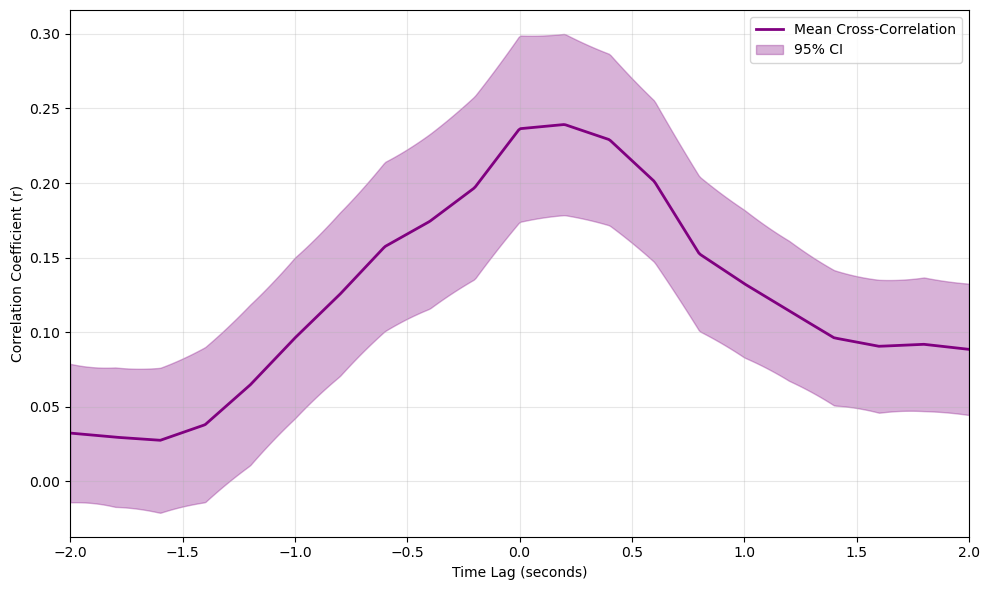

In [46]:
# 1. Create a standardized time axis from -2.0 to 2.0 seconds
common_lags = np.linspace(-2.0, 2.0, 500)
aligned_corrs = []

# 2. Interpolate each underlying trial to match our new standardized axis
for trial in xcorr_data:
    t_lags = trial['time_lags']
    corr = trial['correlation']
    
    # np.interp needs the x-axis to be strictly increasing
    # np.interp(new_x, old_x, old_y)
    interpolated_corr = np.interp(common_lags, t_lags, corr)
    aligned_corrs.append(interpolated_corr)

# 3. Now we can safely stack them because they belong to the exact same 500 points
all_corr_arrays = np.array(aligned_corrs)
n_trials = all_corr_arrays.shape[0]

# 4. Calculate point-by-point Mean, SEM, and 95% CI
mean_corr_line = np.mean(all_corr_arrays, axis=0)
sem_corr_line = stats.sem(all_corr_arrays, axis=0)

# Calculate the Confidence Interval
ci_lower, ci_upper = stats.t.interval(0.95, df=n_trials-1, 
                                      loc=mean_corr_line, 
                                      scale=sem_corr_line)

# 5. Plotting
plt.figure(figsize=(10, 6))

# Plot the Mean Line
plt.plot(common_lags, mean_corr_line, color='purple', linewidth=2, label='Mean Cross-Correlation')

# Shade the Confidence Interval region
plt.fill_between(common_lags, ci_lower, ci_upper, color='purple', alpha=0.3, label='95% CI')

# Formatting
plt.xlabel('Time Lag (seconds)')
plt.ylabel('Correlation Coefficient (r)')
plt.xlim([-2.0, 2.0]) # Matches our interpolated range
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()